# --- 1. Imports ---

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 2. Load Data ---

In [ ]:
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")
df = pd.read_csv(f"{path}/CC GENERAL.csv")
df.tail(2)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8948,C19189,13.457564,0.833333,0.00,0.00,0.0,36.558778,0.000000,0.000000,0.0,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.0,127.040008,0.666667,0.666667,0.0,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


# --- 3. Basic Cleaning ---

In [ ]:
df.drop(columns=["CUST_ID"], inplace=True, errors='ignore')

# Fill missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# --- 4. Feature Scaling ---

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# --- 5. Find Optimal K (Elbow Method) ---

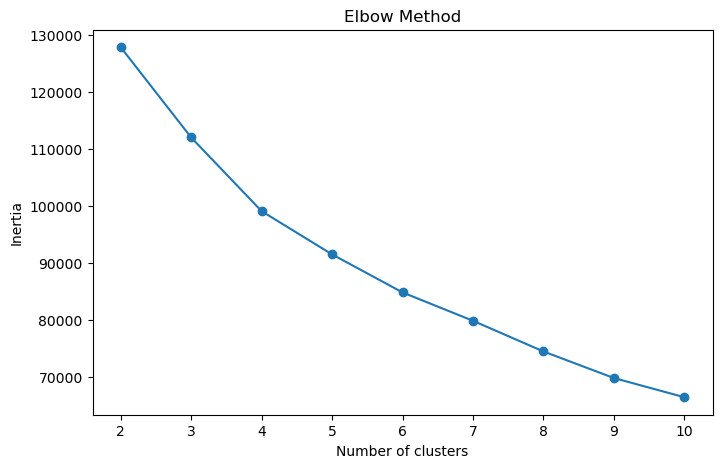

In [ ]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

# --- 6. Silhouette Score (optional but better) ---

In [ ]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

'''
How to interpret: Real-world datasets often give ~0.2–0.4
> 0.5 → strong clustering
0.2 – 0.5 → reasonable
< 0.2 → weak
'''

K=2, Silhouette Score=0.210
K=3, Silhouette Score=0.251
K=4, Silhouette Score=0.198
K=5, Silhouette Score=0.193
K=6, Silhouette Score=0.203
K=7, Silhouette Score=0.208
K=8, Silhouette Score=0.222
K=9, Silhouette Score=0.226
K=10, Silhouette Score=0.220


# --- 7. Final Model (choose best K, e.g., 4) ---

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.640516,974.260054,553.900449,0.077981,11.446568
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1972.767288,0.286707,11.951100
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2003.674460,0.034888,11.386800
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,639.677258,0.269258,11.594595


# --- 8. Cluster Summary ---

In [ ]:
cluster_summary = df.groupby('Cluster').mean()
cluster_summary

'''
How to interpret this
- Each row = one customer segment
- Each value = average behavior of that segment

----------

Step 1: Compare clusters column-wise
Look at one feature at a time:

Example: PURCHASES
Cluster 1 → very high (4500)
Cluster 2 → very low (100)

So:
Cluster 1 = heavy spenders
Cluster 2 = low activity users

----------

Step 2: Combine multiple features

Now look at patterns across columns:

Cluster 1:
High purchases
High credit limit
High payments

Interpretation: “High-value customers”

Cluster 2:
Low balance
Low purchases
Low payments

Interpretation: “Inactive / low engagement customers”

Cluster 3:
High balance
Low purchases
Low payments

Interpretation: “Potentially risky (carrying debt)”
'''

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.640516,974.260054,553.900449,0.077981,11.446568
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1972.767288,0.286707,11.951100
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2003.674460,0.034888,11.386800
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,639.677258,0.269258,11.594595


# --- 9. Visualize (2D projection using PCA) ---

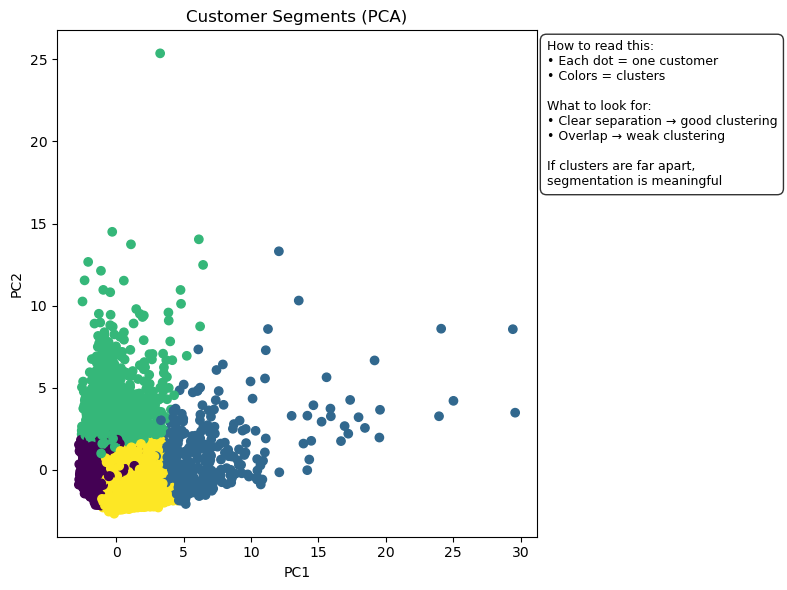

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.title("Customer Segments (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# --- Text box (top-right) ---
text = (
    "How to read this:\n"
    "• Each dot = one customer\n"
    "• Colors = clusters\n\n"
    "What to look for:\n"
    "• Clear separation → good clustering\n"
    "• Overlap → weak clustering\n\n"
    "If clusters are far apart,\n"
    "segmentation is meaningful"
)

plt.gca().text(
    1.02, 0.98, text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

# --- Assign Cluster Names ---

In [ ]:
cluster_names = {
    0: "Low Usage",
    1: "High Value",
    2: "Inactive",
    3: "At Risk"
}

# --- Derived Features ---

In [ ]:
df['UTILIZATION'] = df['BALANCE'] / df['CREDIT_LIMIT']
df['PAYMENT_RATIO'] = df['PAYMENTS'] / df['BALANCE']